<center><h1>Prelab 7: Motion of Charged Particles in Fields Computational Lab

_Name:_ Shikha Nukala

In this week’s lab, you will be using code to simulate the experiment you investigated last week. Specifically, you will test to see how misalignment of the Electric and Magnetic Fields would affect your results. As opposed to previous weeks, you will also be responsible for creating certain code cells to plot and simulate the experiment.

Simulating measurement apparatuses to determine how they will work and what kinds of results you should expect is extremely common in both physics and engineering, especially for precision instruments. In physics, it is typical for an experimentalist to model all of the components of a complicated experimental device, input some (fake) measurement signal, and then determine the output. The same thing happens in engineering, where a complicated machine is modeledcomputationally, and then external stresses are applied so that the tolerances of the gadget can be measured.

In this prelab, we will write a function that we will later use in this week’s lab.

## Assignment

The code we will write uses two packages commonly used in python, `numpy` and `matplotlib.pyplot`. To import these packages, we write the following lines at the top of our file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Since we will be solving problems with vector fields, we should first learn how to manipulate vectors in python. Take for example the Lorentz force equation:

<center>$\vec{F} = q \left( \vec{E} + \vec{v} \times \vec{B} \right)$.

To calculate the force, we must first define the vectors $\vec{E}$, $\vec{v}$, and $\vec{B}$ in our code. There are two ways to define a vector, either write out the components explicitly, or multiply the magnitude by a unit vector. For example, if we wanted to define the $\vec{E}$ vector as an electric field with magnitude`E_field_mag` in the $-\hat{y}$ direction, we could write

In [5]:
#define magntiude in N/C or V/m
E_field_mag = 40e3
#now define the vector
E_field_vec = np.array([0.,-E_field_mag,0.])

or by using a unit vector we can write

In [6]:
#define magntiude in N/C or V/m
E_field_mag = 40e3
#now define the vector
E_field_vec = E_field_mag*np.array([0.,-1.,0.])

**<font color=blue>Prelab Problem 7.1: In your code, define the magnetic field vector with a magnitude `1e-3 #T` in the  $-\hat{z}$ direction. Also define an initial velocity vector with magnitude `3e7 #m/s` in the $+\hat{x}$ direction. Once you have defined the vectors, take the cross product of the two and multiply it by the electron charge to find the Lorentz force due to the magnetic field. Use the function `np.cross(a,b)` which takes as arguments arrays `a` and `b` and returns another array which is the cross product.** 

In [2]:
#####    Begin Editing    #####
#define magnitude in T
B_field_mag = 1e-3
#now define the vector
B_field_vec = [0, 0, -1e-3]

#define magnitude in #m/s
velocity_mag = 3e7
#now define the vector
velocity_vec = [3e7, 0, 0]

#define electron charge in C
q_e = -1.6e-19

#define Lorentz force due to the magnetic field
F_B = q_e * np.cross(velocity_vec, B_field_vec)
    #####     End Editing     #####

In the previous lab we have assumed that the electric and magnetic fields are aligned with our coordinate system. We can code the equations of motion for the particle using the Lorentz force equation, and plot the results to compare our simulation with last week's lab. Newton's second law tells us that

<center>$\vec{F} = m\vec{a} = q\left(\vec{E} + \vec{v} \times \vec{B}\right)$.

We can solve for the acceleration and integrate the equation to find the displacement as a function of time. This is not so straightforward to do analytically, because both the acceleration $\vec{a}$ and velocity $\vec{v}$ change with time. To find a solution to this problem, we can solve the equation iteratively using Python. This is a good example of solving a problem numerically or computationally when an analytic solution is difficult. To begin, let us solve for the acceleration in the above equation.
    
<center>$\vec{a}(t) = \frac{q}{m} \left( \vec{E} + \vec{v}(t) \times \vec{B}\right)$.

The acceleration is defined as $\int \vec{a} dt =\vec{v}$ so we can integrate and find

<center>$\vec{v}(t_f) - \vec{v}(t_i) = \int_{t_i}^{t_f} \frac{q}{m}\left(\vec{E}+\vec{v}(t')\times\vec{B}\right) dt'$.

If we allow for $t_i$ and $t_f$ to be very close together, $t_f - t_i = \Delta t$ we can approximate $v(t')$ as $v(t_i)$ in the integral and find

<center>$\vec{v}(t_i+\Delta t) = \vec{v}(t_i) +  \frac{q}{m}\left(\vec{E}+\vec{v}(t_i)\times\vec{B}\right) \Delta t = \vec{v}(t_i) + \vec{a}(t_i)\Delta t$.

If we have some initial velocity $v(t=0)$ we can use it to find the velocity at $v(0+\Delta t)$. We can then use $v(\Delta t)$ to find the velocity at $v(2\Delta t)$. We can continue this iterative process to find the velocity at any point in the future. Still, we are interested in finding the position as a function of time $\vec{r}(t)=x(t)\hat{x}+y(t)\hat{y}+z(t)\hat{z}$. We can perform a similar process, this time using the equation

<center>$\vec{r}(t_i + \Delta t) = \vec{r}(t_i) + \vec{v}(t_i)\Delta t$.

These last two equations are respectively called the $\textbf{velocity update equation}$ and the $\textbf{position update equation}$. We will now implement them into our code then plot $y(t)$ vs $x(t)$ and compare to our experimental results. We defined the electric field, magnetic field, and initial velocity vectors in the previous part, and now we will combine them to find the Lorentz force on the electron.

**<font color=green>In the following section, we will write detailed code which simulates last week's lab. Write the code along with the manual. The final result will be a set of plots which you will submit to your GSI for credit.** 

We start by defining the electron charge, electron mass, and Lorentz force

<font color=green>**Run the following cell.**

In [3]:
#define electron charge in C
q_e = -1.6e-19
#define the mass of the electron in kg
m_e = 9.11e-31

We will write the Lorentz force as a function since it changes depending on the velocity which is not constant in our setup. To write the vector equation for the Lorentz force, we can make use of numpy's `np.cross(a,b)` which finds the cross product of two 3D arrays, `a` and `b`. Note the placement of the indents before `F = ` and `return F `. These tabs are essential, without them python won't know where to start/stop

<font color = blue> **Prelab Problem 7.2: Define the code for the Lorentz force function, which takes in the parameters for the charge the force is acting on, the velocity of the charge, and the electric and magnetic field the charge is experiencing. Run the code after completing it.**

In [4]:
#Note here we are defining the total Loretnz force, not just the contributions from the B_field
def get_lorentz_force(charge,velocity,Efield,Bfield):
    
        #####    Begin Editing    #####
    F = charge * (Efield + np.cross(velocity, Bfield))
        #####     End Editing     #####
        
    return F

Now we must use our function which finds the Lorentz force in the velocity update equation. We can start by defining useful parameters to solve the problem. 

One important quantity is the characteristic time `tc` which determines how long we need to run the loop. Characteristic time is loosely defined as the ''time it takes for something interesting to happen" (e.g. planetary orbit takes a year to a few years), but can be equally well defined by the dimensionful parameters of the problem. For instance, in last week's lab we found that the electron ejected from the CRT travels close to the speed of light, $v_e=3\times10^{7}$ m/s. If we are interested in tracking the trajectory over a 10 cm by 10 cm area, we can divide $d=10$ cm by $v_e$, $d/v_e$ has units of time and can be used as our characteristic time. 

Another important quantity is `ncycles` which is the number of times we will perform the velocity and position updates. If we perform more updates by increasing $\texttt{ncycles}$, we increase the accuracy of our calculation, but also increase the time it takes for the calculation to be completed. With these things in mind, we can define the parameters of the problem as

<font color = blue> **Prelab Problem 7.3: Insert your solution from Prelab Problem 7.1 in the following code cell to define the initial velocity, electric field, and magnetic field vectors as `myVel`, `myEfield`, and `myBfield`, respectively. Run the code after completing.**

In [5]:
#10cm/v_e characteristic time into
tc = 0.1/3e7

#number of cycles, a larger number divides the time
#smaller steps, which are more accurate but take longer
ncycles = 1e4

#delta_t fom characteristic time and number of cycles
delta_t = tc/ncycles

#intialize time
t=0

    #####    Begin Editing    #####
# use  your  solution  from Prelab Problem 7.1 to fill in these values
myVel = [3e7, 0, 0]
myEfield = [0, 0, 0]
myBfield = [0, 0, -1e-3]
    #####     End Editing     #####

#also define the starting position at (0,0,0)
myPos = np.array([0.,0.,0.])

#finally calculate initial force
myForce = get_lorentz_force(q_e,myVel,myEfield,myBfield)

Apart from the calculation itself, we also need to think about which objects will contain our solution. In Python we can define a list and use the `.append()` function to append as many elements as we would like. Since we are interested in the position as a function of time, we should define a container for that. From a technical standpoint, this isn't always efficient i.e. when you are using large amounts of data. In such cases it is better to use dictionaries or fixed length arrays. Since we aren't dealing with much data, we will use lists. We can also define containers for the velocity and the force if we are interested in plotting those later, as

<font color=green>**Run the following cell.**

In [6]:
listVel=[]
listPos=[]
listForce=[]
listTime=[]

Finally, we can perform the calculation and store the values as we do. Since we are continuously updating the velocity, position, and force, a while loop is the most convenient.

<font color = blue> **Prelab Problem 7.4: Complete the following code cell to calculate the updated position step `newPos` for each time step using `newVel` using Euler's method by approximating `delta_t` is very small. Run the code once finished.**

In [7]:
#add initial values to data container
listVel.append(myVel)
listPos.append(myPos)
listForce.append(myForce)
listTime.append(t)

while t<tc:
    t= t+delta_t
#update velocity using acceleration
    newVel = myVel+(myForce/m_e)*delta_t

        #####    Begin Editing    #####
    #update position using velocity
    newPos = myPos + newVel * delta_t
        #####     End Editing     #####
    
#find new Force based on update velocity
    newForce = get_lorentz_force(q_e,newVel,myEfield,myBfield)

#add new values to lists
    listVel.append(newVel)
    listPos.append(newPos)
    listForce.append(newForce)
    listTime.append(t)
    
#finally, increase time step and
#set new values to 'my' values for next loop
    myVel = newVel
    myPos = newPos
    myForce = newForce

We have just completed a simulation that is similar to a function we will be using in this week's lab to find the trajectory data. Now that we have the trajectory data, we are ready to make plots. Since we have the data, let us plot `myPos`, `myVel`, and `myForce` against time. We can also split `myPos` into $\hat{x}$ and $\hat{y}$ components and plot $x$ vs $y$. We provide the code to plot and save the figure as a PDF to turn in, but you will need to provide appropriate axis labels. **Follow along with the instructions in the lab manual to understand what each section of the following code block does.**

<font color=blue>**Prelab Problem 7.5: Edit the code cell below to add the appropriate titles and axes labels for each of the four plots created. Be sure to look at the `plt.plot` lines prior to creating the labels to verify what plots are being created and what labels are correct. Run the code once finished to generate the plots.**

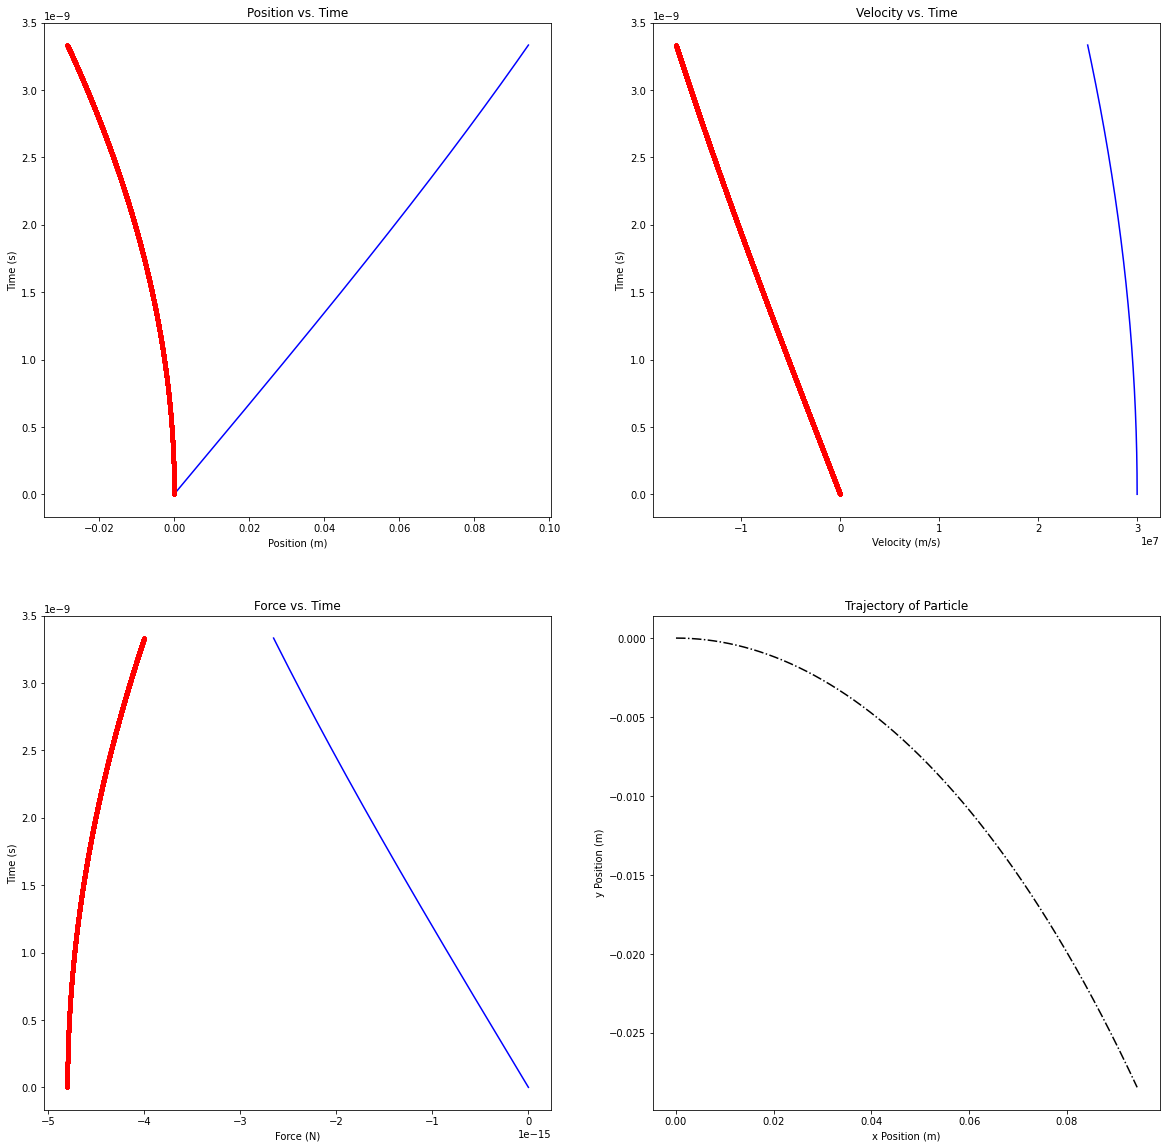

In [9]:
#initialize the figure to plot
plt.figure(figsize=[20,20])

xList=[]
yList=[]
for vector in listPos:
    xList.append(vector[0])
    yList.append(vector[1])
    
plt.subplot(221)
plt.plot(xList,listTime,'b-') #(Note that time is plotted along the y-axis for these plots)
plt.plot(yList,listTime,'r.')

    #####    Begin Editing    #####
#Edit these lines for the labels
plt.title('Position vs. Time')
plt.xlabel('Position (m)')
plt.ylabel('Time (s)')
    #####     End Editing     #####


vxList=[]
vyList=[]

for vector in listVel:
    vxList.append(vector[0])
    vyList.append(vector[1])
    
plt.subplot(222)
plt.plot(vxList,listTime,'b-')
plt.plot(vyList,listTime,'r.')

    #####    Begin Editing    #####
#Edit these lines for the labels
plt.title('Velocity vs. Time')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Time (s)')
    #####     End Editing     #####

FxList=[]
FyList=[]
for vector in listForce:
    FxList.append(vector[0])
    FyList.append(vector[1])
    
plt.subplot(223)
plt.plot(FxList,listTime,'b-')
plt.plot(FyList,listTime,'r.')

    #####    Begin Editing    #####
#Edit these lines for the labels
plt.title('Force vs. Time')
plt.xlabel('Force (N)')
plt.ylabel('Time (s)')
    #####     End Editing     #####

plt.subplot(224)
plt.plot(xList,yList,'k-.')

    #####    Begin Editing    #####
#Edit these lines for the labels
plt.title('Trajectory of Particle')
plt.xlabel('x Position (m)')
plt.ylabel('y Position (m)')
    #####     End Editing     #####
    
plt.show()

The final line displays the plots we created on your screen.

Take a few moments to observe the behavior of the electron with these plots. The $x$ vs $y$ plot will match experimental observations from last week's lab.

### <center>You're done! Submit your pre-lab per the following instructions.

* Save an html version of this file with the pre-lab number and your uniqname to submit to canvas, e.g. `prelab07_bhipsley.html`. If you are woking in Jupyter, you can do this by opening the `File` tab on the top left corner of Jupyter, then select `Save and Export Notebook as > HTML (.html)`. 
* If you are working in Google Colab, first open the `File` tab on the top left corner of Google Colab and select `Download > Download .ipynb` to save the editted file in .ipynb format. Then click `Ctrl-P` (Windows) or `Cmd-P` (Mac) to save the notebook in .pdf format.
* Submit <ins>**both**</ins> the .ipynb and .html (or <ins>**both**</ins> the .ipynb and .pdf) files to canvas under the `Pre-Lab 7: Motion of Charged Particles in Fields Computational` assignment.